![Ironhack logo](https://user-images.githubusercontent.com/23629340/40541063-a07a0a8a-601a-11e8-91b5-2f13e4e6b441.png)

# 02 | Processing and Database Design

*Project 1 — SQL: From Data to Insight*

**Team:**
**Dataset:**

---

Turning one flat file into a relational database: clean the data, split it into tables, wire up the keys, load it into SQLite.

> **Done when:** `data/project.db` exists with 3+ related tables, `sql/schema.sql` matches your ERD, no foreign key is dangling, and the row counts are what you expect.

The sections below are a suggested route, not a form to fill in. Add sections, drop them, reorder them — what is graded is the analysis, not whether you kept the scaffold.

---
## 0. Setup

In [2]:
import sys
sys.path.append("..")          # so `src` is importable from inside notebooks/

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from src.functions import *

pd.set_option("display.max_columns", 100)
sns.set_theme(style="whitegrid")

---
## 1. Load the raw data

In [3]:
from pathlib import Path
raw = Path("../data/raw")

# Load the three World Bank CSV files
data = pd.read_csv(
    raw / "API_Download_DS2_EN_csv_v2_426574.csv",
    skiprows=4
)

countries = pd.read_csv(
    raw / "Metadata_Country_API_Download_DS2_EN_csv_v2_426574.csv"
)

indicators = pd.read_csv(
    raw / "Metadata_Indicator_API_Download_DS2_EN_csv_v2_426574.csv"
)

---
## 2. Clean

Work through the problems you listed in notebook 01. Every decision you make here — drop the nulls or keep them, cast or discard — is one you may be asked to defend on Friday, so note why.

From the World Bank dataset, I decided to keep the missing values during the initial cleaning and dropping them only if they prevent a specific analysis. Applying dropna() to the entire dataset could unnecessarily exclude countries or years from the research.

- If there are missing values --> Exclude from analyses requiring those values (Missing GDP growth or inflation != 0)
- If there is missing country or indicator keys --> nvestigate; exclude invalid records only if unresolved
- If duplicate rows --> remove
- If numbers stored as text --> Convert after checking (Numerical data is required for calculations and statistical analysis.)
- If dates are stored as strings --> Convert to int
- If there are outliers --> Retain unless demonstrably erroneous because extreme inflation or negative GDP growth may reflect genuine economic events (e.g: Russia's invasion of Ukraine)
- Countries outside the EU --> Exclude from sample
- Unnecessary columns --> Remove from tables


In [9]:
#making copies of table to aviod modifying the original data, only for inspection
data_clean = data.copy()
countries_clean = countries.copy()
indicators_clean = indicators.copy()

# Inspect the  datasets before making changes
for name, df in [
    ("Economic data", data_clean),
    ("Countries", countries_clean),
    ("Indicators", indicators_clean)
]:
    print(f"\n--- {name} ---")
    print("Shape:", df.shape)
    print("Duplicate rows:", df.duplicated().sum())

    missing = pd.DataFrame({
        "Missing count": df.isna().sum(),
        "Missing %": (df.isna().mean() * 100).round(2)
    })

    display(missing[missing["Missing count"] > 0])
    print("\nData types:")
    print(df.dtypes)


--- Economic data ---
Shape: (795, 11)
Duplicate rows: 0


,Missing count,Missing %
2019,74,9.31
2020,79,9.94
2021,79,9.94
2022,81,10.19
2023,90,11.32
2024,98,12.33
Unnamed: 10,795,100.00



Data types:
Country Name          str
Country Code          str
Indicator Name        str
Indicator Code        str
2019              float64
2020              float64
2021              float64
2022              float64
2023              float64
2024              float64
Unnamed: 10       float64
dtype: object

--- Countries ---
Shape: (264, 6)
Duplicate rows: 0


,Missing count,Missing %
Region,47,17.80
IncomeGroup,47,17.80
SpecialNotes,130,49.24
Unnamed: 5,264,100.00



Data types:
Country Code        str
Region              str
IncomeGroup         str
SpecialNotes        str
TableName           str
Unnamed: 5      float64
dtype: object

--- Indicators ---
Shape: (3, 5)
Duplicate rows: 0


,Missing count,Missing %
Unnamed: 4,3,100.0



Data types:
INDICATOR_CODE             str
INDICATOR_NAME             str
SOURCE_NOTE                str
SOURCE_ORGANIZATION        str
Unnamed: 4             float64
dtype: object


**Data Standarization:** Removing the whitespace because it can interfere with joins and duplicate detection. Also, unnamed columns provide no analytical information and can be discarded without losing observations. Missing values in meaningful columns are retained for further assessment.

In [10]:
##Standarizing Data
# Removing spaces from column names and text values
for df in [data_clean, countries_clean, indicators_clean]:
    df.columns = df.columns.str.strip()

    for col in df.select_dtypes(
        include=["object", "string"]
    ).columns:
        df[col] = df[col].astype("string").str.strip()
        df[col] = df[col].replace("", pd.NA)

    # Remove unnamed columns only if entirely empty
    empty_columns = [
        col for col in df.columns
        if col.startswith("Unnamed") and df[col].isna().all()
    ]

    df.drop(columns=empty_columns, inplace=True)

---
## 3. Design your tables

Decide what your tables are and how they relate before you write any code. Draw the ERD (Excalidraw, draw.io), export it as an image, commit it, and link it from your README.

Three tables minimum, with real primary and foreign keys.

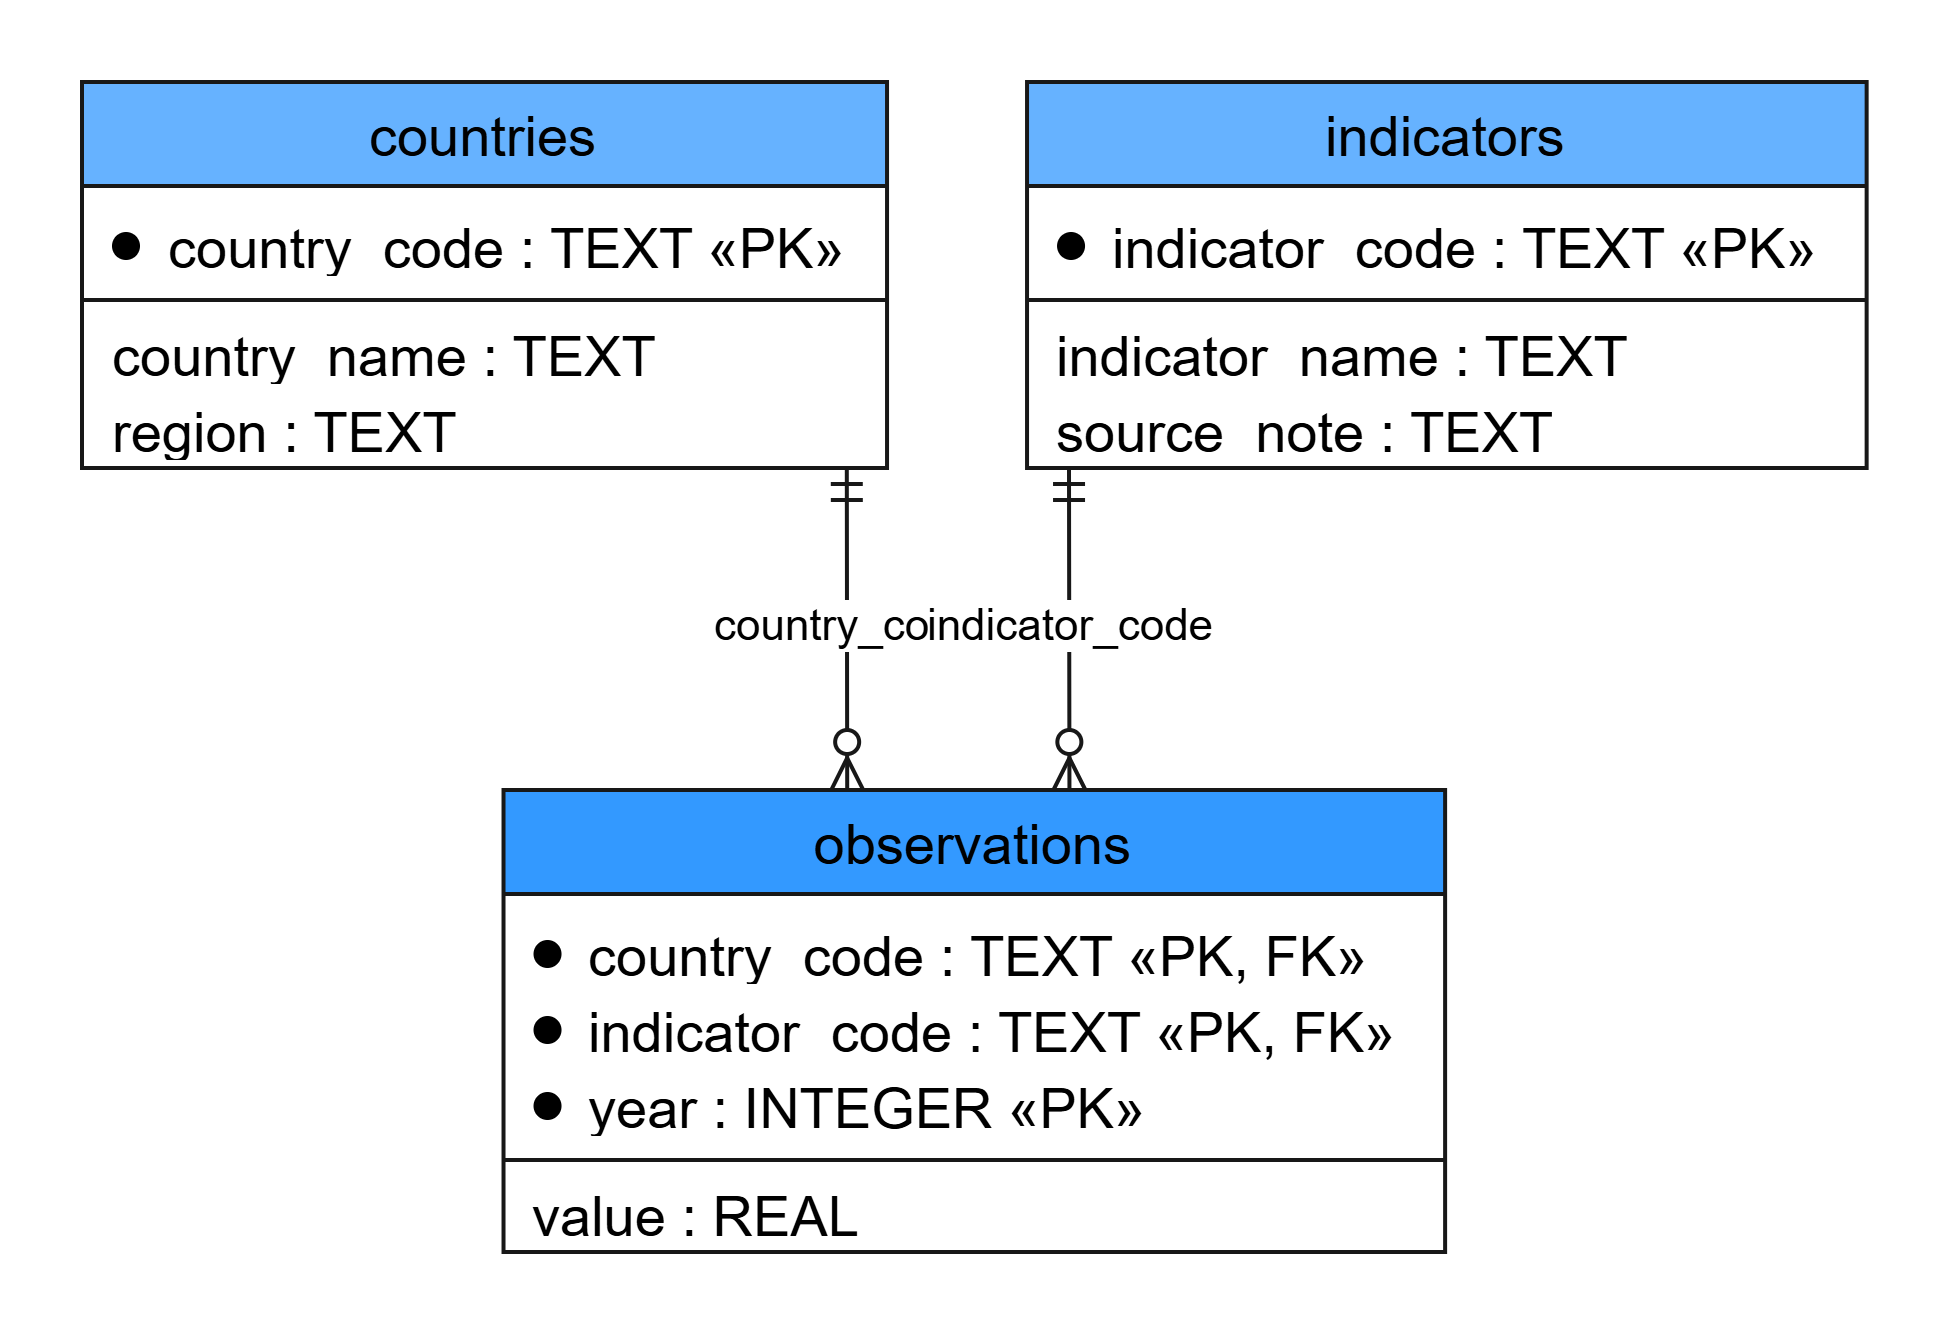

---
## 4. Build the tables

Split the cleaned data into the tables you designed.

In [19]:
## Creating countries table
# Extract unique countries from the economic data
country_names = data_clean[
    ["Country Code", "Country Name"]
].drop_duplicates()

# Add geographical information from country metadata
countries = country_names.merge(
    countries_clean[["Country Code", "Region"]],
    on="Country Code",
    how="left",
    validate="one_to_one"
)

# Rename columns for SQL
countries = countries.rename(columns={
    "Country Code": "country_code",
    "Country Name": "country_name",
    "Region": "region"
})

display(countries.head())
print("Number of countries:", len(countries))

,country_code,country_name,region
0,AUT,Austria,Europe & Central Asia
1,BEL,Belgium,Europe & Central Asia
2,BGR,Bulgaria,Europe & Central Asia
3,CYP,Cyprus,Europe & Central Asia
4,CZE,Czechia,Europe & Central Asia


Number of countries: 27


In [ ]:
##Creating indicators table
indicator_names = data_clean[
    ["Indicator Code", "Indicator Name"]
].drop_duplicates()

# Make a copy of the indicator metadata
metadata = indicators_clean.copy()

# Standardise column names
metadata.columns = (
    metadata.columns
    .str.strip()
    .str.replace(" ", "_")
    .str.upper()
)

# Select the relevant metadata columns
metadata = metadata[
    ["INDICATOR_CODE", "SOURCE_NOTE"]
]

# Rename columns to match the economic data
metadata = metadata.rename(columns={
    "INDICATOR_CODE": "Indicator Code",
    "SOURCE_NOTE": "description"
})

# Merge indicators with their descriptions
indicators = indicator_names.merge(
    metadata,
    on="Indicator Code",
    how="left",
    validate="one_to_one"
)

# Rename columns for SQL
indicators = indicators.rename(columns={
    "Indicator Code": "indicator_code",
    "Indicator Name": "indicator_name"
})

# Add the measurement unit
indicators["unit"] = "%"

# Inspect the result
display(indicators)

print("Number of indicators:", len(indicators))
print("Missing descriptions:", indicators["description"].isna().sum())

,indicator_code,indicator_name,description,unit
0,FP.CPI.TOTL.ZG,"Inflation, consumer prices (annual %)",Inflation as measured by the consumer price in...,%
1,NY.GDP.MKTP.KD.ZG,GDP growth (annual %),Gross domestic product is the total income ear...,%
2,SL.UEM.TOTL.ZS,"Unemployment, total (% of total labor force) (...",Unemployment refers to the share of the labor ...,%


Number of indicators: 3
Missing descriptions: 0


In [25]:
print("Duplicate indicator codes:",
      indicators["indicator_code"].duplicated().sum())

print("Missing indicator codes:",
      indicators["indicator_code"].isna().sum())

Duplicate indicator codes: 0
Missing indicator codes: 0


In [ ]:
##Creating indicators table
# Years included in the project
years = [str(year) for year in range(2019, 2025)]

# Reshape the economic data
observations = data_clean.melt(
    id_vars=["Country Code", "Indicator Code"],
    value_vars=years,
    var_name="year",
    value_name="value"
)

# Rename columns
observations = observations.rename(columns={
    "Country Code": "country_code",
    "Indicator Code": "indicator_code"
})

# Convert to appropriate data types
observations["year"] = observations["year"].astype(int)
observations["value"] = pd.to_numeric(
    observations["value"],
    errors="raise"
)

display(observations.head())
print("Number of observations:", len(observations))

,country_code,indicator_code,year,value
0,AUT,FP.CPI.TOTL.ZG,2019,1.530896
1,AUT,NY.GDP.MKTP.KD.ZG,2019,1.754976
2,AUT,SL.UEM.TOTL.ZS,2019,4.560000
3,BEL,FP.CPI.TOTL.ZG,2019,1.436820
4,BEL,NY.GDP.MKTP.KD.ZG,2019,2.442890


Number of observations: 486


In [27]:
##Checking the tables created correctly:
print("COUNTRIES")
print(countries.shape)
print(countries.dtypes)
display(countries.head())

print("\nINDICATORS")
print(indicators.shape)
print(indicators.dtypes)
display(indicators.head())

print("\nOBSERVATIONS")
print(observations.shape)
print(observations.dtypes)
display(observations.head())

COUNTRIES
(27, 3)
country_code    string
country_name    string
region          string
dtype: object


,country_code,country_name,region
0,AUT,Austria,Europe & Central Asia
1,BEL,Belgium,Europe & Central Asia
2,BGR,Bulgaria,Europe & Central Asia
3,CYP,Cyprus,Europe & Central Asia
4,CZE,Czechia,Europe & Central Asia



INDICATORS
(3, 4)
indicator_code    string
indicator_name    string
description       string
unit                 str
dtype: object


,indicator_code,indicator_name,description,unit
0,FP.CPI.TOTL.ZG,"Inflation, consumer prices (annual %)",Inflation as measured by the consumer price in...,%
1,NY.GDP.MKTP.KD.ZG,GDP growth (annual %),Gross domestic product is the total income ear...,%
2,SL.UEM.TOTL.ZS,"Unemployment, total (% of total labor force) (...",Unemployment refers to the share of the labor ...,%



OBSERVATIONS
(486, 4)
country_code       string
indicator_code     string
year                int64
value             float64
dtype: object


,country_code,indicator_code,year,value
0,AUT,FP.CPI.TOTL.ZG,2019,1.530896
1,AUT,NY.GDP.MKTP.KD.ZG,2019,1.754976
2,AUT,SL.UEM.TOTL.ZS,2019,4.560000
3,BEL,FP.CPI.TOTL.ZG,2019,1.436820
4,BEL,NY.GDP.MKTP.KD.ZG,2019,2.442890


---
## 5. Check the foreign keys

**Do not skip this.** A dangling foreign key is the failure that costs people their Wednesday: the database loads without an error, then your joins silently drop rows and every number is quietly wrong. Check every key value exists in its parent table before you load anything.

In [28]:
print("Duplicate country codes:",
      countries["country_code"].duplicated().sum())

print("Duplicate indicator codes:",
      indicators["indicator_code"].duplicated().sum())

print("Duplicate observations:",
      observations.duplicated(
          subset=["country_code", "indicator_code", "year"]
      ).sum())

Duplicate country codes: 0
Duplicate indicator codes: 0
Duplicate observations: 0


---
## 6. Create the database and load it

Write your `CREATE TABLE` statements in `sql/schema.sql`, then load the tables — parents before children, or the foreign keys will be rejected.

In [31]:
import sqlite3


# Your notebook is inside notebooks/
project_dir = Path(
    r"C:\Users\jjwei\Ironhack-Projects\project-1-eda-sql"
)

schema_path = project_dir / "sql" / "schema.sql"
db_path = project_dir / "data" / "project.db"

# Check that the SQL schema exists
assert schema_path.is_file(), "schema.sql was not found."

# Create the data folder if necessary
db_path.parent.mkdir(parents=True, exist_ok=True)

print("Schema:", schema_path)
print("Database:", db_path)

Schema: C:\Users\jjwei\Ironhack-Projects\project-1-eda-sql\sql\schema.sql
Database: C:\Users\jjwei\Ironhack-Projects\project-1-eda-sql\data\project.db


In [33]:
print(countries.columns.tolist())
print(indicators.columns.tolist())
print(observations.columns.tolist())

['country_code', 'country_name', 'region']
['indicator_code', 'indicator_name', 'description', 'unit']
['country_code', 'indicator_code', 'year', 'value']


In [35]:
assert countries["country_code"].notna().all()
assert countries["country_code"].is_unique

assert indicators["indicator_code"].notna().all()
assert indicators["indicator_code"].is_unique

keys = ["country_code", "indicator_code", "year"]

assert observations[keys].notna().all().all()
assert not observations.duplicated(subset=keys).any()

# Confirm foreign keys are valid
assert observations["country_code"].isin(
    countries["country_code"]
).all()

assert observations["indicator_code"].isin(
    indicators["indicator_code"]
).all()

# Avoid accidentally overwriting an existing database
if db_path.exists():
    raise FileExistsError(
        "project.db already exists. Move or delete it "
        "only if you intend to rebuild the database."
    )

# Connect to SQLite
conn = sqlite3.connect(db_path)

try:
    # SQLite does not enable foreign-key enforcement by default
    conn.execute("PRAGMA foreign_keys = ON;")

    # Create the tables using schema.sql
    with open(schema_path, "r", encoding="utf-8") as file:
        conn.executescript(file.read())

    # Load the parent tables first
    countries.to_sql(
        "countries",
        conn,
        if_exists="append",
        index=False
    )

    indicators.to_sql(
        "indicators",
        conn,
        if_exists="append",
        index=False
    )

    # Load the child table last
    observations.to_sql(
        "observations",
        conn,
        if_exists="append",
        index=False
    )

    print("All three tables loaded successfully.")

finally:
    conn.close()

All three tables loaded successfully.


---
## 7. Verify

Row counts per table, and one join that returns the rows you expect. Then open `data/project.db` in DB Browser and look at it.

In [37]:
conn = sqlite3.connect(db_path)
conn.execute("PRAGMA foreign_keys = ON;")

tables = {
    "countries": countries,
    "indicators": indicators,
    "observations": observations
}

for table_name, df in tables.items():
    count = conn.execute(
        f"SELECT COUNT(*) FROM {table_name}"
    ).fetchone()[0]

    print(f"{table_name}: {count} rows")
    assert count == len(df)

# Check for broken foreign keys
fk_errors = conn.execute(
    "PRAGMA foreign_key_check;"
).fetchall()

print("Foreign-key violations:", len(fk_errors))
assert not fk_errors

# Check that joining the three tables loses no observations
joined_count = conn.execute("""
    SELECT COUNT(*)
    FROM observations AS o
    JOIN countries AS c
        ON o.country_code = c.country_code
    JOIN indicators AS i
        ON o.indicator_code = i.indicator_code;
""").fetchone()[0]

assert joined_count == len(observations)
print("All observations matched their parent tables.")

conn.close()

countries: 27 rows
indicators: 3 rows
observations: 486 rows
Foreign-key violations: 0
All observations matched their parent tables.


In [44]:
query = """
SELECT
    c.country_name,
    i.indicator_name,
    o.year,
    o.value
FROM observations AS o
INNER JOIN countries AS c
    ON o.country_code = c.country_code
INNER JOIN indicators AS i
    ON o.indicator_code = i.indicator_code
WHERE o.country_code = 'DEU'
    AND o.year = 2022
ORDER BY i.indicator_name;
"""

result = pd.read_sql_query(query, conn)

display(result)

,country_name,indicator_name,year,value
0,Germany,GDP growth (annual %),2022,1.809258
1,Germany,"Inflation, consumer prices (annual %)",2022,6.872574
2,Germany,"Unemployment, total (% of total labor force) (...",2022,3.137000


In [45]:
conn = sqlite3.connect("../data/project.db")